# Analyzing log files

In [ ]:
from matplotlib import gridspec
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from loguru import logger
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap
from adjustText import adjust_text
from coevolution.utils.log_parser import parse_coevolution_log

import networkx as nx
from pyvis.network import Network
import os


# --- 3. Analysis ---

def plot_fitness_dynamics(gen_df: pd.DataFrame) -> None:
    """
    Plots the average, min, and max probabilities for both populations.
    """
    if gen_df.empty:
        print("Generation summary DataFrame is empty. Skipping plot.")
        return

    print("--- Plotting Population Fitness Dynamics ---")
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot average probabilities
    gen_df['avg_code_prob'].plot(ax=ax, label='Avg. Code Prob.', color='blue', lw=2)
    gen_df['avg_test_prob'].plot(ax=ax, label='Avg. Test Prob.', color='red', lw=2)


    ax.set_title('Coevolutionary Fitness Dynamics')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Probability (Fitness)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def build_lineage_graph(ind_df: pd.DataFrame) -> nx.DiGraph | None:
    """
    Builds and returns a NetworkX graph of the full lineage.
    
    Handles the 'ParentDict' structure where parents are grouped by type 
    (e.g., {'code': ['C1'], 'test': ['T1']}), allowing for cross-species 
    lineage tracking (Code <-> Test).

    Args:
        ind_df: DataFrame containing individual records with a 'parents' column
                containing dictionaries.

    Returns:
        nx.DiGraph or None if input is empty.
    """
    if ind_df.empty:
        logger.warning("Individual DataFrame is empty. Skipping lineage graph.")
        return None

    logger.info("Building Lineage Graph...")
    G = nx.DiGraph()

    for _, row in ind_df.iterrows():
        child_id = row['id']
        
        # 1. Add the Child Node
        # We use .get() to safely handle potential missing columns in the log
        G.add_node(
            child_id,
            type=row.get('type', 'Unknown'),
            status=row.get('status', 'Unknown'),
            prob=row.get('probability', 0.0),
            gen_born=row.get('generation_born', -1),
            op=row.get('creation_op', 'Unknown')
        )
        
        # 2. Extract Parents
        # The 'parents' column contains a dict: {'code': ['id1'], 'test': ['id2']}
        parents_data = row.get('parents', {})
        
        # Handle cases where parents might be NaN/None (e.g. generation 0)
        if not isinstance(parents_data, dict):
            continue

        # 3. Iterate over Parent Types (Code parents, Test parents)
        for parent_type, parent_ids in parents_data.items():
            if not isinstance(parent_ids, list):
                continue
                
            for parent_id in parent_ids:
                # Ensure parent node exists (phantom parents from previous runs/generations)
                if not G.has_node(parent_id):
                    # We infer the type from the dictionary key ('code' or 'test')
                    G.add_node(
                        parent_id, 
                        type=parent_type.capitalize(), # 'Code' or 'Test'
                        status='Ancestor' 
                    )
                
                # Add the edge
                # We attribute the edge with the relationship type
                G.add_edge(parent_id, child_id, parent_type=parent_type)

    logger.success(f"Graph created: {G.number_of_nodes()} individuals, {G.number_of_edges()} lineage connections.")
    return G

def get_ancestral_subgraph(G: nx.DiGraph, target_id: str) -> nx.DiGraph:
    """
    Extracts the direct lineage leading to a specific individual.
    
    Args:
        G: The full population graph.
        target_id: The ID of the individual to trace (e.g., the final best Code).
        
    Returns:
        A small subgraph containing only the target and its direct ancestors.
    """
    if target_id not in G:
        print(f"Error: Target ID {target_id} not found in graph.")
        return nx.DiGraph()

    # 1. Find all ancestors (recursive upstream search)
    ancestors = nx.ancestors(G, target_id)
    
    # 2. Include the target itself
    nodes_to_keep = ancestors | {target_id}
    
    # 3. Create the subgraph
    # .copy() ensures we don't modify the original massive graph
    subgraph = G.subgraph(nodes_to_keep).copy()
    
    print(f"Tracing lineage for {target_id}: Reduced {len(G)} nodes -> {len(subgraph)} relevant ancestors.")
    return subgraph

def visualize_lineage_interactive(
    G: nx.DiGraph, 
    output_file: str = "coevolution_lineage.html"
) -> None:
    """
    Generates a high-performance interactive graph with explicit 'Zipper' layout.
    
    Fixes:
    - "Alternating View": Manually places Code vertically between Test generations.
    """
    if G is None or G.number_of_nodes() == 0:
        print("Graph is empty, nothing to visualize.")
        return

    print(f"Generating optimized interactive graph to {output_file}...")

    # --- 1. Initialize PyVis (No Physics/Layout Presets) ---
    # We turn off the 'hierarchical' preset because we are doing it manually.
    net = Network(height="95vh", width="100%", bgcolor="#ffffff", font_color="black", directed=True)
    
    # Strictly disable physics to prevent browser crash
    net.set_options("""
    var options = {
      "physics": {
        "enabled": false
      },
      "interaction": {
        "dragNodes": true,
        "hideEdgesOnDrag": false,
        "hideNodesOnDrag": false
      },
      "edges": {
        "smooth": {
          "type": "cubicBezier",
          "forceDirection": "vertical",
          "roundness": 0.4
        }
      }
    }
    """)

    # --- 2. Calculate Swimlane Widths ---
    grouped_nodes = defaultdict(lambda: defaultdict(list))
    max_width_per_type = defaultdict(int)
    
    for node, data in G.nodes(data=True):
        pop_type = data.get('type', 'unknown').lower()
        gen = data.get('gen_born', -1)
        if gen == -1: gen = 0
        grouped_nodes[pop_type][gen].append(node)
        # Track max density to size the lanes
        max_width_per_type[pop_type] = max(max_width_per_type[pop_type], len(grouped_nodes[pop_type][gen]))

    # --- 3. Define Layout Constants ---
    # X-Axis Spacing
    NODE_WIDTH = 100       # Horizontal space per node
    LANE_PADDING = 300     # Gap between population types
    
    # Y-Axis Spacing (The Zipper)
    GEN_HEIGHT = 400       # Vertical space for one full generation step
    CODE_OFFSET = 200      # How far down Code sits relative to Tests of same gen

    # Calculate Lane Centers
    current_x = 0
    lane_centers = {}
    
    # Order: Tests Left, Code Right (Visual flow: Tests -> Code)
    ordered_types = ['unittest', 'differential', 'public', 'code', 'unknown']
    
    for p_type in ordered_types:
        if p_type not in max_width_per_type: continue
        lane_width = max_width_per_type[p_type] * NODE_WIDTH
        lane_centers[p_type] = current_x + (lane_width / 2)
        current_x += lane_width + LANE_PADDING

    # --- 4. Place Nodes (Manual X/Y) ---
    for node, data in G.nodes(data=True):
        pop_type = data.get('type', 'unknown').lower()
        gen = data.get('gen_born', 0)
        status = data.get('status', 'Unknown')
        
        # --- CALCULATE Y (The Interleaved Logic) ---
        base_y = gen * GEN_HEIGHT
        
        if 'code' in pop_type:
            # Code is pushed down by half a step
            y_pos = base_y + CODE_OFFSET
        else:
            # Tests sit at the "top" of the generation
            y_pos = base_y

        # --- CALCULATE X (Centering) ---
        nodes_in_row = grouped_nodes[pop_type][gen]
        # Sort by ID to ensure consistent placement
        sorted_nodes = sorted(nodes_in_row)
        try:
            idx = sorted_nodes.index(node)
        except ValueError:
            idx = 0
            
        lane_center = lane_centers.get(pop_type, 0)
        row_width = (len(nodes_in_row) - 1) * NODE_WIDTH
        start_x = lane_center - (row_width / 2)
        x_pos = start_x + (idx * NODE_WIDTH)

        # --- STYLING ---
        color = "#97c2fc"
        shape = "dot"
        size = 20  # Default size
        
        if 'code' in pop_type:
            color = "#3498db" # Blue
            shape = "dot"
            size = 25
        elif 'unittest' in pop_type:
            color = "#2ecc71" # Green
            shape = "square"
        elif 'differential' in pop_type:
            color = "#e67e22" # Orange
            shape = "triangle"
            size = 15 # Slightly smaller to handle density
        elif 'public' in pop_type:
            color = "#9b59b6" # Purple
            shape = "diamond"

        # Highlight Survivors
        border_width = 1
        if status == 'SURVIVED':
            border_width = 3
            # Make survivors slightly larger
            size += 5
        else:
            # Fade out dead nodes slightly
            color = f"{color}80" # Add hex transparency (approximate support)

        # Tooltip
        title = (
            f"<b>{node}</b><br>"
            f"Type: {pop_type}<br>"
            f"Gen: {gen}<br>"
            f"Status: {status}<br>"
            f"Prob: {data.get('prob', 0.0):.4f}"
        )

        net.add_node(
            node,
            label=str(node),
            title=title,
            color=color,
            shape=shape,
            size=size,
            borderWidth=border_width,
            x=x_pos, 
            y=y_pos,
            physics=False,  # CRITICAL: Disable physics per node
            fixed=True      # CRITICAL: Lock position so they don't drift
        )

    # --- 5. Add Edges ---
    for u, v, data in G.edges(data=True):
        p_type = data.get('parent_type', 'unknown')
        target_status = G.nodes[v].get('status', 'Unknown')
        
        color = '#bdc3c7' # Default faint gray
        width = 1
        
        # Color by parent type
        if p_type == 'code': color = '#3498db'
        elif p_type == 'test': color = '#2ecc71'
        
        # Emphasize Survivor Paths
        if target_status == 'SURVIVED':
            width = 3
            # Keep original color
        else:
            # Fade dead edges significantly
            color = 'rgba(200, 200, 200, 0.3)'

        net.add_edge(
            u, v,
            color=color,
            width=width,
            arrows='to',
            physics=False
        )

    # --- 6. Save ---
    net.save_graph(output_file)
    print(f"Interactive visualization saved: {os.path.abspath(output_file)}")

def visualize_lineage(G: nx.DiGraph) -> None:
    """
    Creates a detailed plot of the coevolution lineage DiGraph
    using a Stratified Hierarchical Layout with ALTERNATING spacing.
    
    Layout Logic:
    - X-Axis: Grouped by Population Type (Swimlanes).
    - Y-Axis: Generations flow downwards.
    - Alternating: Code is visually offset by 0.5 generations to appear 
                   BETWEEN test generations (Zipper effect).
    """
    if G is None or G.number_of_nodes() == 0:
        print("Graph is empty, nothing to visualize.")
        return

    print("Generating alternating stratified lineage visualization...")
    plt.figure(figsize=(20, 15))

    # --- 1. Visual Styles ---
    styles = {
        'code':         {'color': '#3498db', 'shape': 'o', 'label': 'Code'},
        'unittest':     {'color': '#2ecc71', 'shape': 's', 'label': 'Unittest'},
        'differential': {'color': '#e67e22', 'shape': '^', 'label': 'Differential'},
        'public':       {'color': '#9b59b6', 'shape': 'd', 'label': 'Public'},
        'unknown':      {'color': '#95a5a6', 'shape': '8', 'label': 'Unknown'}
    }

    # --- 2. Compute Layout (Alternating Zipper) ---
    pos = {}
    
    # Swimlane Centers
    lane_centers = {
        'code': 0.0,
        'unittest': 20.0, 
        'differential': 40.0,
        'public': 60.0
    }
    default_lane_x = 80.0
    
    # Group nodes
    grouped_nodes = defaultdict(lambda: defaultdict(list))
    for node, data in G.nodes(data=True):
        pop_type = data.get('type', 'unknown').lower()
        if pop_type not in styles: pop_type = 'unknown'
        gen = data.get('gen_born', -1)
        if gen == -1: gen = -0.5
        grouped_nodes[pop_type][gen].append(node)

    # Spacing Constants
    x_spacing = 1.5   # Horizontal space between nodes
    y_spacing = -3.0  # Vertical space per full generation (Negative = Down)

    for pop_type, gens in grouped_nodes.items():
        lane_x = lane_centers.get(pop_type, default_lane_x)
        
        for gen, nodes in gens.items():
            # --- THE ALTERNATING LOGIC ---
            # If it's Code, push it down by 0.5 generations (1.5 units)
            # Standard Gen Y:  gen * -3.0
            # Offset Code Y:   (gen + 0.5) * -3.0
            
            effective_gen = gen
            if 'code' in pop_type and gen >= 0:
                 effective_gen += 0.5
            
            y_pos = effective_gen * y_spacing

            # --- Centering Logic ---
            num_nodes = len(nodes)
            start_x = lane_x - ((num_nodes - 1) * x_spacing) / 2.0
            
            for i, node in enumerate(sorted(nodes)):
                pos[node] = (start_x + (i * x_spacing), y_pos)

    # --- 3. Draw Nodes (Iterate by Type) ---
    legend_handles = []
    present_types = set(d.get('type', 'unknown').lower() for _, d in G.nodes(data=True))
    present_types = {t if t in styles else 'unknown' for t in present_types}

    for pop_type in styles:
        if pop_type not in present_types and pop_type != 'unknown': continue
            
        style = styles[pop_type]
        
        # Filter nodes
        nodelist = [
            n for n, d in G.nodes(data=True) 
            if d.get('type', 'unknown').lower() == pop_type 
            or (pop_type == 'unknown' and d.get('type', 'unknown').lower() not in styles)
        ]
        
        if not nodelist: continue

        # Determine colors (Solid for Survivor, Faint for Died)
        node_colors = []
        edge_colors = []
        for n in nodelist:
            status = G.nodes[n].get('status', 'Unknown')
            if status == 'SURVIVED':
                node_colors.append(style['color'])
                edge_colors.append('black') # Bold border
            else:
                # To make "Faint" colors in Matplotlib without complex RGBA logic per node,
                # we usually just use the same color but handle it via global alpha.
                # Here we keep same color but white border implies 'weak'.
                node_colors.append(style['color']) 
                edge_colors.append('white') 
        
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodelist,
            node_shape=style['shape'],
            node_color=node_colors,
            edgecolors=edge_colors,
            linewidths=1.5,
            node_size=600,
            alpha=0.9,
            label=style['label']
        )
        
        legend_handles.append(
            plt.Line2D([0], [0], marker=style['shape'], color='w', label=style['label'],
                      markerfacecolor=style['color'], markersize=10, markeredgecolor='black')
        )

    # --- 4. Draw Edges ---
    edge_colors = []
    for u, v, data in G.edges(data=True):
        p_type = data.get('parent_type', 'unknown')
        if p_type == 'code': edge_colors.append('#3498db')
        elif p_type == 'test': edge_colors.append('#2ecc71')
        else: edge_colors.append('#bdc3c7')

    nx.draw_networkx_edges(
        G, pos,
        edge_color=edge_colors,
        width=1.0, alpha=0.4,
        arrows=True, arrowsize=15,
        connectionstyle='arc3,rad=0.1' 
    )

    # --- 5. Decoration ---
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

    # Draw Swimlane Separators
    ax = plt.gca()
    sorted_centers = sorted(lane_centers.values())
    mid_points = [(a + b) / 2 for a, b in zip(sorted_centers, sorted_centers[1:])]
    ymin, ymax = ax.get_ylim()
    
    for mid in mid_points:
        plt.vlines(mid, ymin, ymax, colors='gray', linestyles=':', alpha=0.3)
        
    for p_type, center_x in lane_centers.items():
        if p_type in present_types:
            # Place label slightly above the highest node
            plt.text(center_x, 1.0, p_type.upper(), 
                     ha='center', fontsize=12, fontweight='bold', 
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    plt.title("Alternating Coevolution Lineage (Ancestral Trace)", fontsize=18)
    
    status_legend = [
        plt.Line2D([0], [0], marker='o', color='w', label='Survivor',
                  markerfacecolor='gray', markeredgecolor='black', markeredgewidth=1.5),
        plt.Line2D([0], [0], marker='o', color='w', label='Died',
                  markerfacecolor='gray', markeredgecolor='white', markeredgewidth=0)
    ]
    
    first_legend = plt.legend(handles=legend_handles, title="Population Type", loc='upper left')
    plt.gca().add_artist(first_legend)
    plt.legend(handles=status_legend, title="Status", loc='lower left')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def get_discriminations(matrix_df: pd.DataFrame) -> dict[str, int]:
    """
    Computes the number of discriminations for each test in the observation matrix.
    A discrimination occurs when a test passes for some codes and fails for others.

    Returns a dictionary mapping test names to their discrimination counts.
    """
    discriminations: dict[str, int] = {}

    # convert DataFrame to numpy array for efficient processing
    mat: np.ndarray = matrix_df.values
    discrimination_array = ParetoSystem.calculate_discrimination(mat)
    for col_idx, test_name in enumerate(matrix_df.columns):
        discriminations[test_name] = discrimination_array[col_idx]

    return discriminations


def create_events_df(ind_df):
    """
    Un-nests the 'lifecycle_events' column from the main
    individual DataFrame into a tidy, flat DataFrame.
    """
    # 1. 'Explode' the list into new rows
    flat_df = ind_df.explode('lifecycle_events')

    # 2. Flatten the 'lifecycle_events' dictionary
    # Handle NaNs (for individuals with no events) gracefully
    flat_df['lifecycle_events'] = flat_df['lifecycle_events'].fillna({})
    event_series = flat_df['lifecycle_events'].apply(pd.Series)

    # 3. Flatten the 'details' dictionary
    # Handle empty details dicts (like for 'selected_as_elite')
    if 'details' not in event_series.columns:
        event_series['details'] = [{}] * len(event_series)
        
    event_series['details'] = event_series['details'].fillna({})
    details_series = event_series['details'].apply(pd.Series)

    # 4. Concatenate everything back together
    # --- THIS IS THE FIX ---
    # We drop both 'lifecycle_events' AND the conflicting 'probability' 
    # column from the original flat_df.
    final_df = pd.concat(
        [
            flat_df.drop(['lifecycle_events', 'probability'], axis=1), # <-- MODIFIED
            event_series.drop(['details'], axis=1),
            details_series
        ], 
        axis=1
    )
    
    # Clean up and reset the index
    final_df = final_df.reset_index(drop=True)
    
    # We need a numeric generation column for plotting
    if 'generation' in final_df.columns:
        final_df['generation'] = pd.to_numeric(final_df['generation'])
    
    return final_df



def plot_lifecycle_timeline(ind_type_df:pd.DataFrame, tidy_events_df:pd.DataFrame) -> None:
    """
    Plots a Gantt-style chart showing the lifespan and key
    events for each individual.
    """
        
    # 1. Get the lifespan (start and end generation) for each individual
    # We sort by 'generation_born' so the chart is ordered
    lifespan_df = ind_type_df.sort_values(by='generation_born', ascending=False)
    
    # Get the last recorded generation for each individual
    last_gen = tidy_events_df.groupby('id')['generation'].max()
    lifespan_df['gen_end'] = lifespan_df['id'].map(last_gen)
    
    # Set a default end for any missing (shouldn't happen)
    lifespan_df['gen_end'] = lifespan_df['gen_end'].fillna(lifespan_df['generation_born'])
    
    # Calculate bar length
    lifespan_df['lifespan'] = lifespan_df['gen_end'] - lifespan_df['generation_born'] + 1
    
    # 2. Get the key events to plot as markers
    events_to_plot = tidy_events_df[
        tidy_events_df['event'].isin(['became_parent', 'selected_as_elite'])
    ]

    # --- 3. Plot ---
    print("Plotting lifecycle timeline...")
    fig, ax = plt.subplots(figsize=(14, 10))

    # Create a y-position for each individual
    id_list = lifespan_df['id'].tolist()
    y_pos = np.arange(len(id_list))

    # Plot the main lifespan bars
    ax.barh(
        y_pos,
        lifespan_df['lifespan'],
        left=lifespan_df['generation_born'],
        align='center',
        height=0.6,
        alpha=0.3,
        color=lifespan_df['status'].map({'SURVIVED': 'green', 'DIED': 'gray'})
    )

    # --- 4. Plot event markers ---
    
    # Map IDs to their y-position
    id_to_y = {id_name: y for id_name, y in zip(id_list, y_pos)}

    # Plot 'became_parent' events
    parent_events = events_to_plot[events_to_plot['event'] == 'became_parent']
    ax.scatter(
        parent_events['generation'],
        parent_events['id'].map(id_to_y),
        color='blue',
        marker='^',
        s=100,
        label='Became Parent'
    )

    # Plot 'selected_as_elite' events
    elite_events = events_to_plot[events_to_plot['event'] == 'selected_as_elite']
    ax.scatter(
        elite_events['generation'],
        elite_events['id'].map(id_to_y),
        color='gold',
        marker='*',
        s=150,
        label='Selected as Elite'
    )
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(id_list)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Individual ID')
    ax.set_title('Individual Lifecycle Timeline')
    ax.legend(loc='best')
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def get_test_gen_prob_vs_discrimination(
    test_events_df: pd.DataFrame,
    generated_observation_matrices: list[pd.DataFrame]
) -> pd.DataFrame:
    """
    For each test and generation, get the last recorded probability
    and the discrimination from the generated observation matrix.

    Returns a tidy DataFrame with columns:
    - generation
    - id (test name)
    - probability
    - discrimination
    """

    # 1) Probabilities: take last probability per (generation, id)
    prob_df = (
        test_events_df[test_events_df['event'] == 'probability_updated']
        .loc[:, ['generation', 'id', 'probability']]
        .dropna(subset=['probability'])
        .assign(probability=lambda d: pd.to_numeric(d['probability'], errors='coerce'))
        .groupby(['generation', 'id'], observed=True, as_index=False)['probability']
        .last()
    )

    # 2) Discriminations: build long DataFrame from generated_observation_matrices
    disc_rows = []
    for gen_idx, mat_df in enumerate(generated_observation_matrices[:-1]):
        discs = get_discriminations(mat_df)
        for test_name, disc in discs.items():
            disc_rows.append({'generation': int(gen_idx), 'id': test_name, 'discrimination': float(disc)})
    discrimination_df = pd.DataFrame(disc_rows)

    # 3) Merge into a tidy table
    test_gen_df = pd.merge(
        prob_df,
        discrimination_df,
        on=['generation', 'id'],
        how='outer'   # keep tests that appear in either source
    )

    # 4) Clean types and fill-missing discrimination (0.0 means no discrimination detected)
    test_gen_df['generation'] = test_gen_df['generation'].astype(int)
    test_gen_df['probability'] = test_gen_df['probability'].astype(float)
    test_gen_df['discrimination'] = test_gen_df['discrimination'].fillna(0.0).astype(float)

    # 5) Sort for convenience
    test_gen_df = test_gen_df.sort_values(['generation', 'id']).reset_index(drop=True)

    return test_gen_df

def plot_test_prob_vs_discrimination(test_gen_df: pd.DataFrame) -> None:
    """
    Plot test probs vs discriminations over generations. subplots per generation.
    """
    generations = test_gen_df['generation'].unique()
    num_gens = len(generations)
    
    fig, axes = plt.subplots(
        nrows=1, 
        ncols=num_gens, 
        figsize=(5 * num_gens, 5), 
        sharey=True
    )
    
    if num_gens == 1:
        axes = [axes]  # make it iterable
    
    for ax, gen in zip(axes, generations):
        gen_data = test_gen_df[test_gen_df['generation'] == gen]
        
        ax.scatter(
            gen_data['discrimination'],
            gen_data['probability'],
            s=100,
            alpha=0.2,
            edgecolors='w'
        )
        
        ax.set_title(f'Generation {gen}')
        ax.set_xlabel('Discrimination')
        ax.set_ylabel('Probability')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, 1.1)
        
    
    plt.tight_layout()
    plt.show()

def create_code_progression_df(events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Converts the long code_events_df into a wide one with one row
    per individual per generation, showing the probability at each stage.

    This function goes directly from the raw events_df to the final wide
    progression DataFrame.

    Args:
        events_df: The raw, exploded code_events_df.

    Returns:
        A DataFrame with columns:
        [id, generation, before_update, after_public_update, 
         after_generated_update, status]
    """
    
    # --- Step 1: Get 'created' probabilities ---
    # This is our 'before_update' for the generation_born
    created_df = events_df[events_df['event'] == 'created'][
        ['id', 'generation', 'probability']
    ].rename(columns={'probability': 'before_update'})
    
    # --- Step 2: Get and Pivot 'probability_updated' events ---
    
    # We must sort by the original index to preserve event order
    prob_updates = events_df[
        events_df['event'] == 'probability_updated'
    ].copy()
    
    # Use reset_index() in case the index name isn't 'original_index'
    prob_updates = prob_updates.reset_index().rename(
        columns={'index': 'original_index'}
    )
    prob_updates = prob_updates.sort_values(
        by=['id', 'generation', 'original_index']
    )
    
    # Assign update numbers (1 = PUBLIC, 2 = GENERATED)
    prob_updates['update_num'] = prob_updates.groupby(
        ['id', 'generation']
    ).cumcount() + 1
    
    # Pivot the updates into two separate columns
    df_public = prob_updates[prob_updates['update_num'] == 1][
        ['id', 'generation', 'probability']
    ].rename(columns={'probability': 'after_public_update'})
    
    df_generated = prob_updates[prob_updates['update_num'] == 2][
        ['id', 'generation', 'probability']
    ].rename(columns={'probability': 'after_generated_update'})
    
    # --- Step 3: Merge all probability stages together ---
    
    # Merge public and generated updates
    progression_df = pd.merge(
        df_public,
        df_generated,
        on=['id', 'generation'],
        how='outer'
    )
    
    # Merge the 'created' (before_update) values
    progression_df = pd.merge(
        progression_df,
        created_df,
        on=['id', 'generation'],
        how='outer'
    )
    
    # --- Step 4: Fill 'before_update' for surviving individuals ---
    # This is the trickiest part. 'before_update' is NaN for any
    # generation *after* the individual was born. We must fill it
    # with the last known probability from the *previous* generation.
    
    # Sort by ID and Generation to allow for correct shifting
    progression_df = progression_df.sort_values(by=['id', 'generation'])
    
    # Find the last known probability for each row (gen)
    # This is the generated prob, or public prob, or created prob
    progression_df['last_prob_of_gen'] = (
        progression_df['after_generated_update']
        .fillna(progression_df['after_public_update'])
        .fillna(progression_df['before_update'])
    )
    
    # Shift this value down (by 1) within each ID group
    progression_df['prev_gen_last_prob'] = progression_df.groupby('id')[
        'last_prob_of_gen'
    ].shift(1)
    
    # Use this shifted value to fill the NaNs in 'before_update'
    progression_df['before_update'] = progression_df['before_update'].fillna(
        progression_df['prev_gen_last_prob']
    )

    # --- Step 5: Add final 'status' ---
    status_df = events_df[
        ['id', 'status']
    ].drop_duplicates(subset=['id'], keep='last')
    
    progression_df = pd.merge(progression_df, status_df, on='id', how='left')
    
    # --- Step 6: Final Cleanup ---
    final_cols = [
        'id', 
        'generation', 
        'before_update', 
        'after_public_update', 
        'after_generated_update', 
        'status'
    ]
    
    # Drop rows that have no probability data at all
    # (e.g., if an individual was created but never updated, 
    # and we only merged on update DFs)
    # The 'last_prob_of_gen' col is a good proxy for "has data"
    progression_df = progression_df.dropna(subset=['last_prob_of_gen'])
    
    return progression_df[final_cols].reset_index(drop=True)

def create_test_progression_df(events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Converts the long test_events_df into a wide one with one row
    per individual per generation, showing the probability at each stage.

    This function goes directly from the raw events_df to the final wide
    progression DataFrame.

    Args:
        events_df: The raw, exploded test_events_df.

    Returns:
        A DataFrame with columns:
        [id, generation, before_update, after_update, status]
    """
    
    # --- Step 1: Get 'created' probabilities ---
    # This is our 'before_update' for the generation_born
    created_df = events_df[events_df['event'] == 'created'][
        ['id', 'generation', 'probability']
    ].rename(columns={'probability': 'before_update'})
    
    # --- Step 2: Get the single 'probability_updated' event ---
    
    # We must sort by the original index to preserve event order
    prob_updates = events_df[
        events_df['event'] == 'probability_updated'
    ].copy()
    
    # Use reset_index() in case the index name isn't 'original_index'
    prob_updates = prob_updates.reset_index().rename(
        columns={'index': 'original_index'}
    )
    prob_updates = prob_updates.sort_values(
        by=['id', 'generation', 'original_index']
    )
    
    # Assign update numbers (we only care about the first one)
    prob_updates['update_num'] = prob_updates.groupby(
        ['id', 'generation']
    ).cumcount()
    
    # Pivot the first update into the 'after_update' column
    df_update = prob_updates[prob_updates['update_num'] == 0][
        ['id', 'generation', 'probability']
    ].rename(columns={'probability': 'after_update'})
    
    # --- Step 3: Merge all probability stages together ---
    
    # Merge the 'created' (before_update) and 'after_update' values
    progression_df = pd.merge(
        created_df,
        df_update,
        on=['id', 'generation'],
        how='outer'
    )
    
    # --- Step 4: Fill 'before_update' for surviving individuals ---
    # 'before_update' is NaN for any generation *after* the individual
    # was born. We must fill it with the last known probability.
    
    # Sort by ID and Generation to allow for correct shifting
    progression_df = progression_df.sort_values(by=['id', 'generation'])
    
    # Find the last known probability for each row (gen)
    # This is the 'after_update', or the 'before_update' (from 'created')
    progression_df['last_prob_of_gen'] = (
        progression_df['after_update']
        .fillna(progression_df['before_update'])
    )
    
    # Shift this value down (by 1) within each ID group
    progression_df['prev_gen_last_prob'] = progression_df.groupby('id')[
        'last_prob_of_gen'
    ].shift(1)
    
    # Use this shifted value to fill the NaNs in 'before_update'
    progression_df['before_update'] = progression_df['before_update'].fillna(
        progression_df['prev_gen_last_prob']
    )

    # --- Step 5: Add final 'status' ---
    status_df = events_df[
        ['id', 'status']
    ].drop_duplicates(subset=['id'], keep='last')
    
    progression_df = pd.merge(progression_df, status_df, on='id', how='left')
    
    # --- Step 6: Final Cleanup ---
    final_cols = [
        'id', 
        'generation', 
        'before_update', 
        'after_update', 
        'status'
    ]
    
    # Drop rows that have no probability data at all
    progression_df = progression_df.dropna(subset=['last_prob_of_gen'])
    
    return progression_df[final_cols].reset_index(drop=True)

# Enhanced color palette
COLORS = {
    'code': '#5B9BD5',      # Softer blue
    'test': '#70AD47',      # Softer green
    'matrix_neg': '#F4B4B4', # Pastel red
    'matrix_pos': '#B4E7CE', # Pastel green
    'bg_public': '#F8F9FA',
    'bg_generated': '#FFFFFF'
}

# --- Helper 1: Code Probabilities (Horizontal) ---
def plot_code_prob_barchart(prob_data, prob_column, title, ax, aligned_rows):
    """
    Plots a HORIZONTAL bar chart for code probabilities onto a specific axes.
    Aligns the y-axis to the matrix's row (Code) index.
    """
    ax.set_xlim(0, 1)
    
    if prob_data.empty or (aligned_rows is None or len(aligned_rows) == 0):
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                transform=ax.transAxes, color='#CCCCCC', fontsize=11, style='italic')
        ax.set_title(title, fontsize=11, pad=8)
        ax.set_xlabel("Probability", fontsize=9)
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    # Align data to the matrix's row index
    plot_data = prob_data.set_index('id').reindex(aligned_rows)
    
    # Use the actual index for y-positioning to maintain order
    y_positions = np.arange(len(plot_data))
    bars = ax.barh(
        y=y_positions, 
        width=plot_data[prob_column],
        color=COLORS['code'],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_data.index, fontsize=9)
    ax.invert_yaxis()  # Invert to match matrix order (top to bottom)
    ax.set_title(title, fontsize=11, pad=8, weight='semibold')
    ax.set_xlabel("Probability", fontsize=9)
    ax.set_ylabel(None)
    ax.grid(axis='x', linestyle=':', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

# --- Helper 2: Test Probabilities (Vertical) ---
def plot_test_prob_barchart(prob_data, prob_column, title, ax, aligned_cols):
    """
    Plots a VERTICAL bar chart for test probabilities onto a specific axes.
    Aligns the x-axis to the matrix's column (Test) index.
    """
    ax.set_ylim(0, 1)
    
    if prob_data.empty or (aligned_cols is None or len(aligned_cols) == 0):
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                transform=ax.transAxes, color='#CCCCCC', fontsize=11, style='italic')
        ax.set_title(title, fontsize=11, pad=8)
        ax.set_ylabel("Probability", fontsize=9)
        ax.set_xticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    # Align data to the matrix's column index
    plot_data = prob_data.set_index('id').reindex(aligned_cols)
    
    # Use the actual index for x-positioning to maintain order
    x_positions = np.arange(len(plot_data))
    bars = ax.bar(
        x=x_positions,
        height=plot_data[prob_column],
        color=COLORS['test'],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_data.index, rotation=90, fontsize=9, ha='center')
    ax.set_title(title, fontsize=11, pad=8, weight='semibold')
    ax.set_ylabel("Probability", fontsize=9)
    ax.set_xlabel(None)
    ax.grid(axis='y', linestyle=':', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

# --- Helper 3: Matrix Heatmap ---
def plot_matrix_heatmap(df, title, ax):
    """
    Plots the observation matrix DataFrame as a heatmap onto a specific axes.
    """
    if df is None or df.empty:
        ax.text(0.5, 0.5, 'No Matrix Data', ha='center', va='center', 
                transform=ax.transAxes, color='#CCCCCC', fontsize=11, style='italic')
        ax.set_title(title, fontsize=11, pad=8)
        ax.set_xticks([])
        ax.set_yticks([])
        return

    mat = df.astype(int).clip(0, 1)
    cmap = ListedColormap([COLORS['matrix_neg'], COLORS['matrix_pos']])

    sns.heatmap(
        mat,
        cmap=cmap,
        linewidths=0.8,
        linecolor='white',
        cbar=False,
        square=False,
        vmin=0,
        vmax=1,
        ax=ax
    )
    ax.set_title(title, fontsize=11, pad=8, weight='semibold')
    ax.set_xlabel("Test ID", fontsize=9, labelpad=5)
    ax.set_ylabel(None)
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

# --- Helper 4: Placeholder for empty plots ---
def plot_placeholder(ax, title=""):
    """Fills an axes with a subtle placeholder."""
    ax.set_facecolor('#FAFAFA')
    ax.text(0.5, 0.5, '—', ha='center', va='center', 
            transform=ax.transAxes, color='#DDDDDD', fontsize=24, weight='light')
    if title:
        ax.set_title(title, fontsize=11, pad=8, color='#999999')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


# --- UPDATED MAIN FUNCTION ---

def plot_full_coevolution_dashboard(
    code_progression_df, 
    test_progression_df, 
    public_matrices, 
    generated_matrices,
    private_matrices, # New argument: List of 2 dataframes [initial, final]
    output_dir="."
):
    """
    Plots the full coevolution dashboard as a single figure.
    
    Order of rows:
    1. Initial Private Matrix (Ground Truth Start)
    2. Gen 0 PUBLIC
    3. Gen 0 GENERATED
    ...
    4. Gen N PUBLIC
    5. Gen N GENERATED
    6. Final Private Matrix (Ground Truth End)
    """
    
    # 1. Find all generations to plot
    gens_code = code_progression_df['generation'].unique()
    gens_test = test_progression_df['generation'].unique()
    all_gens = sorted(list(set(gens_code) | set(gens_test)))
    
    # Calculate total rows: (Generations * 2) + 2 Private Matrices
    n_evo_rows = len(all_gens) * 2
    n_total_rows = n_evo_rows + 2
    
    if n_evo_rows == 0:
        print("No event data to plot.")
        return

    # 2. Create Figure
    fig = plt.figure(figsize=(28, n_total_rows * 7.5))
    fig.patch.set_facecolor('white')
    fig.suptitle("Co-evolution Probability and Matrix Progression", 
                 fontsize=22, weight='bold', color='#333333', y=0.995)
    
    # Outer grid
    outer_gs = gridspec.GridSpec(n_total_rows, 1, figure=fig, hspace=0.4, top=0.96, bottom=0.02)

    # --- A: Plot INITIAL PRIVATE Matrix (Row 0) ---
    row_idx = 0
    
    # Get initial matrix (first element)
    init_matrix = private_matrices[0] if private_matrices and len(private_matrices) > 0 else None
    
    # Create subgrid
    gs_init = outer_gs[row_idx].subgridspec(1, 5, width_ratios=[1.2, 1.2, 3, 1.2, 1.2], wspace=0.15)
    
    ax_init_code_b = fig.add_subplot(gs_init[0, 0])
    ax_init_test_b = fig.add_subplot(gs_init[0, 1])
    ax_init_matrix = fig.add_subplot(gs_init[0, 2])
    ax_init_code_a = fig.add_subplot(gs_init[0, 3])
    ax_init_test_a = fig.add_subplot(gs_init[0, 4])
    
    # Label
    ax_init_code_b.set_ylabel("INITIAL\nPRIVATE\n(Ground Truth)", fontsize=12, weight='bold', 
                             color='#333333', labelpad=10)
    
    # Plot
    plot_placeholder(ax_init_code_b)
    plot_placeholder(ax_init_test_b)
    plot_matrix_heatmap(init_matrix, "Initial Private Matrix", ax_init_matrix)
    plot_placeholder(ax_init_code_a)
    plot_placeholder(ax_init_test_a)


    # --- B: Loop through Generations (Rows 1 to N) ---
    # We offset the row index by 1 because row 0 is taken
    
    for i, gen in enumerate(all_gens):
        
        # --- Get Data ---
        prob_code_gen = code_progression_df[code_progression_df['generation'] == gen]
        prob_test_gen = test_progression_df[test_progression_df['generation'] == gen]

        # --- Plot PUBLIC Row ---
        row_idx = (i * 2) + 1 # Offset by 1
        
        matrix_pub = public_matrices[gen] if gen < len(public_matrices) else None
        aligned_rows_pub = matrix_pub.index if matrix_pub is not None else (
            prob_code_gen['id'].sort_values().unique() if not prob_code_gen.empty else None
        )
        
        gs_pub = outer_gs[row_idx].subgridspec(1, 5, width_ratios=[1.2, 1.2, 3, 1.2, 1.2], wspace=0.15)
        
        ax_pub_code_b = fig.add_subplot(gs_pub[0, 0], facecolor=COLORS['bg_public'])
        ax_pub_test_b = fig.add_subplot(gs_pub[0, 1])
        ax_pub_matrix = fig.add_subplot(gs_pub[0, 2], facecolor=COLORS['bg_public'])
        ax_pub_code_a = fig.add_subplot(gs_pub[0, 3], facecolor=COLORS['bg_public'])
        ax_pub_test_a = fig.add_subplot(gs_pub[0, 4])
        
        ax_pub_code_b.set_ylabel(f"Gen {gen}\nPUBLIC", fontsize=12, weight='bold', color='#333333', labelpad=10)
        
        plot_code_prob_barchart(prob_code_gen, 'before_update', 'Code Prob (Before)', ax_pub_code_b, aligned_rows_pub)
        plot_placeholder(ax_pub_test_b, 'Test Prob (Before)')
        plot_matrix_heatmap(matrix_pub, f"Gen {gen} - PUBLIC Matrix", ax_pub_matrix)
        plot_code_prob_barchart(prob_code_gen, 'after_public_update', 'Code Prob (After)', ax_pub_code_a, aligned_rows_pub)
        plot_placeholder(ax_pub_test_a, 'Test Prob (After)')

        # --- Plot GENERATED Row ---
        row_idx = (i * 2) + 2 # Offset by 1
        
        matrix_gen = generated_matrices[gen] if gen < len(generated_matrices) else None
        aligned_rows_gen = matrix_gen.index if matrix_gen is not None else (
            prob_code_gen['id'].sort_values().unique() if not prob_code_gen.empty else None
        )
        aligned_cols_gen = matrix_gen.columns if matrix_gen is not None else (
            prob_test_gen['id'].sort_values().unique() if not prob_test_gen.empty else None
        )
        
        gs_gen = outer_gs[row_idx].subgridspec(1, 5, width_ratios=[1.2, 1.2, 3, 1.2, 1.2], wspace=0.15)
        
        ax_gen_code_b = fig.add_subplot(gs_gen[0, 0], facecolor=COLORS['bg_generated'])
        ax_gen_test_b = fig.add_subplot(gs_gen[0, 1], facecolor=COLORS['bg_generated'])
        ax_gen_matrix = fig.add_subplot(gs_gen[0, 2], facecolor=COLORS['bg_generated'])
        ax_gen_code_a = fig.add_subplot(gs_gen[0, 3], facecolor=COLORS['bg_generated'])
        ax_gen_test_a = fig.add_subplot(gs_gen[0, 4], facecolor=COLORS['bg_generated'])
        
        ax_gen_code_b.set_ylabel(f"Gen {gen}\nGENERATED", fontsize=12, weight='bold', color='#333333', labelpad=10)
        
        plot_code_prob_barchart(prob_code_gen, 'after_public_update', 'Code Prob (Before)', ax_gen_code_b, aligned_rows_gen)
        plot_test_prob_barchart(prob_test_gen, 'before_update', 'Test Prob (Before)', ax_gen_test_b, aligned_cols_gen)
        plot_matrix_heatmap(matrix_gen, f"Gen {gen} - GENERATED Matrix", ax_gen_matrix)
        plot_code_prob_barchart(prob_code_gen, 'after_generated_update', 'Code Prob (After)', ax_gen_code_a, aligned_rows_gen)
        plot_test_prob_barchart(prob_test_gen, 'after_update', 'Test Prob (After)', ax_gen_test_a, aligned_cols_gen)


    # --- C: Plot FINAL PRIVATE Matrix (Last Row) ---
    row_idx = n_total_rows - 1
    
    # Get final matrix (last element)
    final_matrix = private_matrices[-1] if private_matrices and len(private_matrices) > 0 else None
    
    gs_final = outer_gs[row_idx].subgridspec(1, 5, width_ratios=[1.2, 1.2, 3, 1.2, 1.2], wspace=0.15)
    
    ax_final_code_b = fig.add_subplot(gs_final[0, 0])
    ax_final_test_b = fig.add_subplot(gs_final[0, 1])
    ax_final_matrix = fig.add_subplot(gs_final[0, 2])
    ax_final_code_a = fig.add_subplot(gs_final[0, 3])
    ax_final_test_a = fig.add_subplot(gs_final[0, 4])
    
    ax_final_code_b.set_ylabel("FINAL\nPRIVATE\n(Ground Truth)", fontsize=12, weight='bold', 
                               color='#333333', labelpad=10)
    
    plot_placeholder(ax_final_code_b)
    plot_placeholder(ax_final_test_b)
    plot_matrix_heatmap(final_matrix, "Final Private Matrix", ax_final_matrix)
    plot_placeholder(ax_final_code_a)
    plot_placeholder(ax_final_test_a)

    # 3. Show Plot
    plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
    plt.show()

def plot_test_probability_progression(progression_df: pd.DataFrame):
    """
    Plots the probability progression for all TEST individuals in a single line plot.
    
    The x-axis is categorical:
    [Gen 0-Before, Gen 0-After, Gen 1-Before, ...]
    
    Annotates the final point of each individual with its ID and a
    marker (o for SURVIVED, x for DIED).

    Args:
        progression_df: The wide DataFrame from create_test_progression_df().
    """
    
    # --- 1. Data "Melt" ---
    # Melt the test progression df (only two value_vars)
    plot_df = pd.melt(
        progression_df,
        id_vars=['id', 'generation', 'status'],
        value_vars=[
            'before_update', 
            'after_update'
        ],
        var_name='stage_name',
        value_name='probability'
    )

    # --- 2. Create Categorical X-Axis ---
    # Simplified stage map for tests
    stage_map = {
        'before_update': ('A_Before', 'Before'),
        'after_update': ('B_After', 'After')
    }
    
    plot_df['stage_sort'] = plot_df['stage_name'].map(lambda x: stage_map.get(x, ('Z_Other', 'Other'))[0])
    plot_df['stage_label'] = plot_df['stage_name'].map(lambda x: stage_map.get(x, ('Z_Other', 'Other'))[1])

    plot_df['x_tick'] = plot_df.apply(
        lambda row: f"Gen {row['generation']}\n{row['stage_label']}", 
        axis=1
    )
    
    plot_df = plot_df.sort_values(by=['id', 'generation', 'stage_sort'])
    plot_df = plot_df.dropna(subset=['probability'])
    
    x_axis_order = plot_df.drop_duplicates(
        subset=['generation', 'stage_sort']
    ).sort_values(by=['generation', 'stage_sort'])['x_tick'].unique()

    # Convert x_tick column to a Categorical type
    plot_df['x_tick'] = pd.Categorical(
        plot_df['x_tick'],
        categories=x_axis_order,
        ordered=True
    )

    # --- 3. Plotting ---
    plt.figure(figsize=(22, 10))
    
    ax = sns.lineplot(
        data=plot_df,
        x='x_tick',
        y='probability',
        hue='id',
        legend=False,
        marker='o',
        markersize=4,
        alpha=0.6,
        palette='plasma' # Use a different palette to distinguish from code
    )
    
    # --- 4. Annotation (with adjustText) ---
    last_points_df = plot_df.groupby('id').last().reset_index()
    
    texts = []

    for _, row in last_points_df.iterrows():
        marker = 'x' if row['status'] == 'DIED' else 'o'
        color = '#d9534f' if row['status'] == 'DIED' else '#5cb85c'
        
        texts.append(ax.text(
            x=row['x_tick'], 
            y=row['probability'], 
            s=f" {row['id']}",
            color='black',
            fontsize=9,
            verticalalignment='center',
            horizontalalignment='left'
        ))
        
        ax.plot(
            [row['x_tick']], [row['probability']],
            marker=marker,
            markersize=8,
            color=color,
            linestyle='none',
            markeredgewidth=2.5
        )

    # Run the adjustment
    adjust_text(
        texts, 
        ax=ax, 
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.7)
    )

    # --- 5. Final Plot Tweaks ---
    ax.set_title('Test Individual Probability Progression', fontsize=18)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_xlabel('Generation and Update Stage', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

def plot_code_probability_progression(code_progression_df: pd.DataFrame):
    """
    Plots the probability progression for all individuals in a single line plot.
    
    The x-axis is categorical:
    [Gen 0-Before, Gen 0-Public, Gen 0-Generated, Gen 1-Before, ...]
    
    Annotates the final point of each individual with its ID and a
    marker (o for SURVIVED, x for DIED).

    Args:
        progression_df: The wide DataFrame from create_progression_df().
    """
    
    # --- 1. Data "Melt" ---
    plot_df = pd.melt(
        code_progression_df,
        id_vars=['id', 'generation', 'status'],
        value_vars=[
            'before_update', 
            'after_public_update', 
            'after_generated_update'
        ],
        var_name='stage_name',
        value_name='probability'
    )

    # --- 2. Create Categorical X-Axis ---
    stage_map = {
        'before_update': ('A_Before', 'Before'),
        'after_public_update': ('B_Public', 'Public'),
        'after_generated_update': ('C_Generated', 'Generated')
    }
    
    plot_df['stage_sort'] = plot_df['stage_name'].map(lambda x: stage_map.get(x, ('Z_Other', 'Other'))[0])
    plot_df['stage_label'] = plot_df['stage_name'].map(lambda x: stage_map.get(x, ('Z_Other', 'Other'))[1])

    plot_df['x_tick'] = plot_df.apply(
        lambda row: f"Gen {row['generation']}\n{row['stage_label']}", 
        axis=1
    )
    
    plot_df = plot_df.sort_values(by=['id', 'generation', 'stage_sort'])
    plot_df = plot_df.dropna(subset=['probability'])
    
    x_axis_order = plot_df.drop_duplicates(
        subset=['generation', 'stage_sort']
    ).sort_values(by=['generation', 'stage_sort'])['x_tick'].unique()

    plot_df['x_tick'] = pd.Categorical(
        plot_df['x_tick'],
        categories=x_axis_order,
        ordered=True
    )

    # --- 3. Plotting ---
    plt.figure(figsize=(22, 10))
    
    ax = sns.lineplot(
        data=plot_df,
        x='x_tick',
        y='probability',
        hue='id',
        legend=False,
        marker='o',
        markersize=4,
        alpha=0.6,
        palette='viridis'
    )
    
    # --- 4. Annotation (with adjustText) ---
    last_points_df = plot_df.groupby('id').last().reset_index()
    
    # Create a list to store the text objects
    texts = []

    for _, row in last_points_df.iterrows():
        marker = 'x' if row['status'] == 'DIED' else 'o'
        color = '#d9534f' if row['status'] == 'DIED' else '#5cb85c'
        
        # Create the text object and append it to our list
        texts.append(ax.text(
            x=row['x_tick'], 
            y=row['probability'], 
            s=f" {row['id']}",
            color='black',
            fontsize=9,
            verticalalignment='center',
            horizontalalignment='left'
        ))
        
        # Plot the end marker (this is fine)
        ax.plot(
            [row['x_tick']], [row['probability']],
            marker=marker,
            markersize=8,
            color=color,
            linestyle='none',
            markeredgewidth=2.5
        )

    # --- 4b. Run the adjustment ---
    # This will automatically move labels to prevent overlap
    # It will also draw small lines back to the original point
    adjust_text(
        texts, 
        ax=ax, 
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.7)
    )

    # --- 5. Final Plot Tweaks ---
    ax.set_title('Code Individual Probability Progression', fontsize=18)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_xlabel('Generation and Update Stage', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    
    plt.tight_layout()
    plt.show()

2026-01-05 15:38:58.755 | INFO     | coevolution.utils.log_parser:_log_line_generator:51 - Streaming: coevolution_run_20260105.2026-01-05_01-20-16_582290.log.zip
2026-01-05 15:39:03.642 | INFO     | coevolution.utils.log_parser:_log_line_generator:51 - Streaming: coevolution_run_20260105.2026-01-05_13-46-15_137105.log.zip
2026-01-05 15:39:08.318 | INFO     | coevolution.utils.log_parser:_log_line_generator:51 - Streaming: coevolution_run_20260105.2026-01-05_15-07-12_446118.log.zip
2026-01-05 15:39:13.799 | INFO     | coevolution.utils.log_parser:_log_line_generator:51 - Streaming: coevolution_run_20260105.2026-01-05_15-19-28_009791.log
2026-01-05 15:39:14.237 | INFO     | coevolution.utils.log_parser:_log_line_generator:51 - Streaming: coevolution_run_20260105.2026-01-05_15-19-28_009791.log.zip
2026-01-05 15:39:14.237 | ERROR    | coevolution.utils.log_parser:_log_line_generator:64 - Failed to read ../../../logs/coevolution_run_20260105.2026-01-05_15-19-28_009791.log.zip: File is not a

--- Analysis for Run: simplediffs, Problem: abc396_e ---

--- Generation Summary (Head) ---
            code_pop_size  ...                               differential_new_ids
generation                 ...                                                   
0                      10  ...                                                 []
0                      10  ...                                                 []
1                      15  ...  [T579, T580, T581, T582, T583, T584, T585, T58...

[3 rows x 18 columns]

--- Individual Data (Head) ---
    id  type status  generation_born
0  C84  code   DIED                0
1  C86  code   DIED                0
2  C88  code   DIED                0
3  C89  code   DIED                0
4  C90  code   DIED                0
--- Plotting Population Fitness Dynamics ---
An unexpected error occurred: 'avg_test_prob'


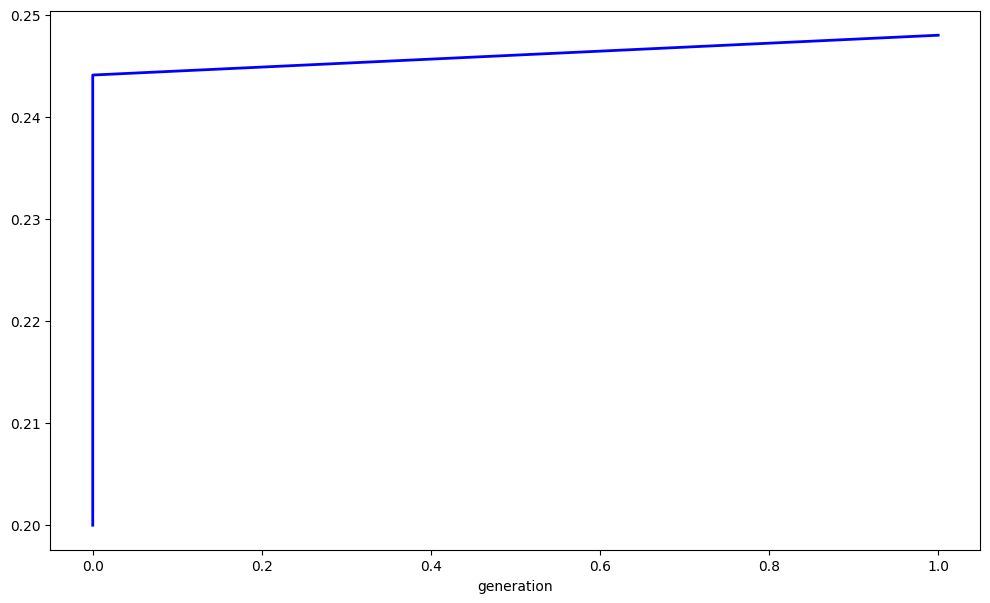

In [6]:
import sys

LOG_FOLDER = '../../../logs/'
LOG_FILE_PATTERN = 'coevolution_run_20260105.*log*'
RUN_TO_ANALYZE = 'simplediffs'
PROBLEM_TO_ANALYZE = 'abc396_e'

logger.remove()
logger.add(sys.stderr, level="DEBUG")

try:
    # Pass the targets to the parsing function
    results = parse_coevolution_log(LOG_FOLDER, LOG_FILE_PATTERN, 
                                            RUN_TO_ANALYZE, 
                                            PROBLEM_TO_ANALYZE)
    
    gen_df = results['gen_stats']
    ind_df = results['individuals']
    matrices = results['matrices']
    
    public_observation_matrices = matrices['public']
    private_observation_matrices = matrices['private'] 
    unittest_observation_matrices = matrices['unittest']
    differential_observation_matrices = matrices['differential']
    
    print(f"--- Analysis for Run: {RUN_TO_ANALYZE}, Problem: {PROBLEM_TO_ANALYZE} ---")

    if gen_df.empty and ind_df.empty:
        print("No matching data found.")
    
    else:
        if not gen_df.empty:
            print("\n--- Generation Summary (Head) ---")
            print(gen_df.head())
        
        if not ind_df.empty:
            print("\n--- Individual Data (Head) ---")
            print(ind_df[['id', 'type', 'status', 'generation_born']].head())
                
        plot_fitness_dynamics(gen_df)
        lineage_graph = build_lineage_graph(ind_df)
    
    if len(unittest_observation_matrices) == 0:
        print("\nNo Unittest Observation Matrices found.")
    if len(differential_observation_matrices) == 0:
        print("\nNo Differential Observation Matrices found.")
    if len(public_observation_matrices) == 0:
        print("\nNo Public Observation Matrices found.")
    if len(private_observation_matrices) == 0:
        print("\nNo Private Observation Matrices found.")

except FileNotFoundError:
    print(f"Error: Log file not found at '{LOG_FILE_PATTERN}'")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [39]:
gen_df

,code_pop_size,avg_code_prob,min_code_prob,max_code_prob,new_code_count,new_code_ids,unittest_pop_size,unittest_avg_prob,unittest_min_prob,unittest_max_prob,unittest_new_count,unittest_new_ids,differential_pop_size,differential_avg_prob,differential_min_prob,differential_max_prob,differential_new_count,differential_new_ids
generation,,,,,,,,,,,,,,,,,,
0,10,0.2000,0.2000,0.2000,10,"[C81, C82, C83, C84, C85, C86, C87, C88, C89, ...",1,0.200,0.200,0.200,1,[T535],0,0.0000,0.0000,0.0000,0,[]
0,10,0.2441,0.1060,0.2717,10,"[C81, C82, C83, C84, C85, C86, C87, C88, C89, ...",1,0.192,0.192,0.192,1,[T535],100,0.2000,0.2000,0.2000,0,[]
1,15,0.2480,0.1079,0.2765,10,"[C91, C92, C93, C94, C95, C96, C97, C98, C99, ...",1,0.192,0.192,0.192,0,[],100,0.1994,0.1952,0.2035,100,"[T579, T580, T581, T582, T583, T584, T585, T58..."


2026-01-05 17:37:56.656 | INFO     | __main__:build_lineage_graph:64 - Building Lineage Graph...
2026-01-05 17:37:56.660 | SUCCESS  | __main__:build_lineage_graph:108 - Graph created: 121 individuals, 216 lineage connections.


Tracing lineage for C96: Reduced 121 nodes -> 5 relevant ancestors.
Generating alternating stratified lineage visualization...


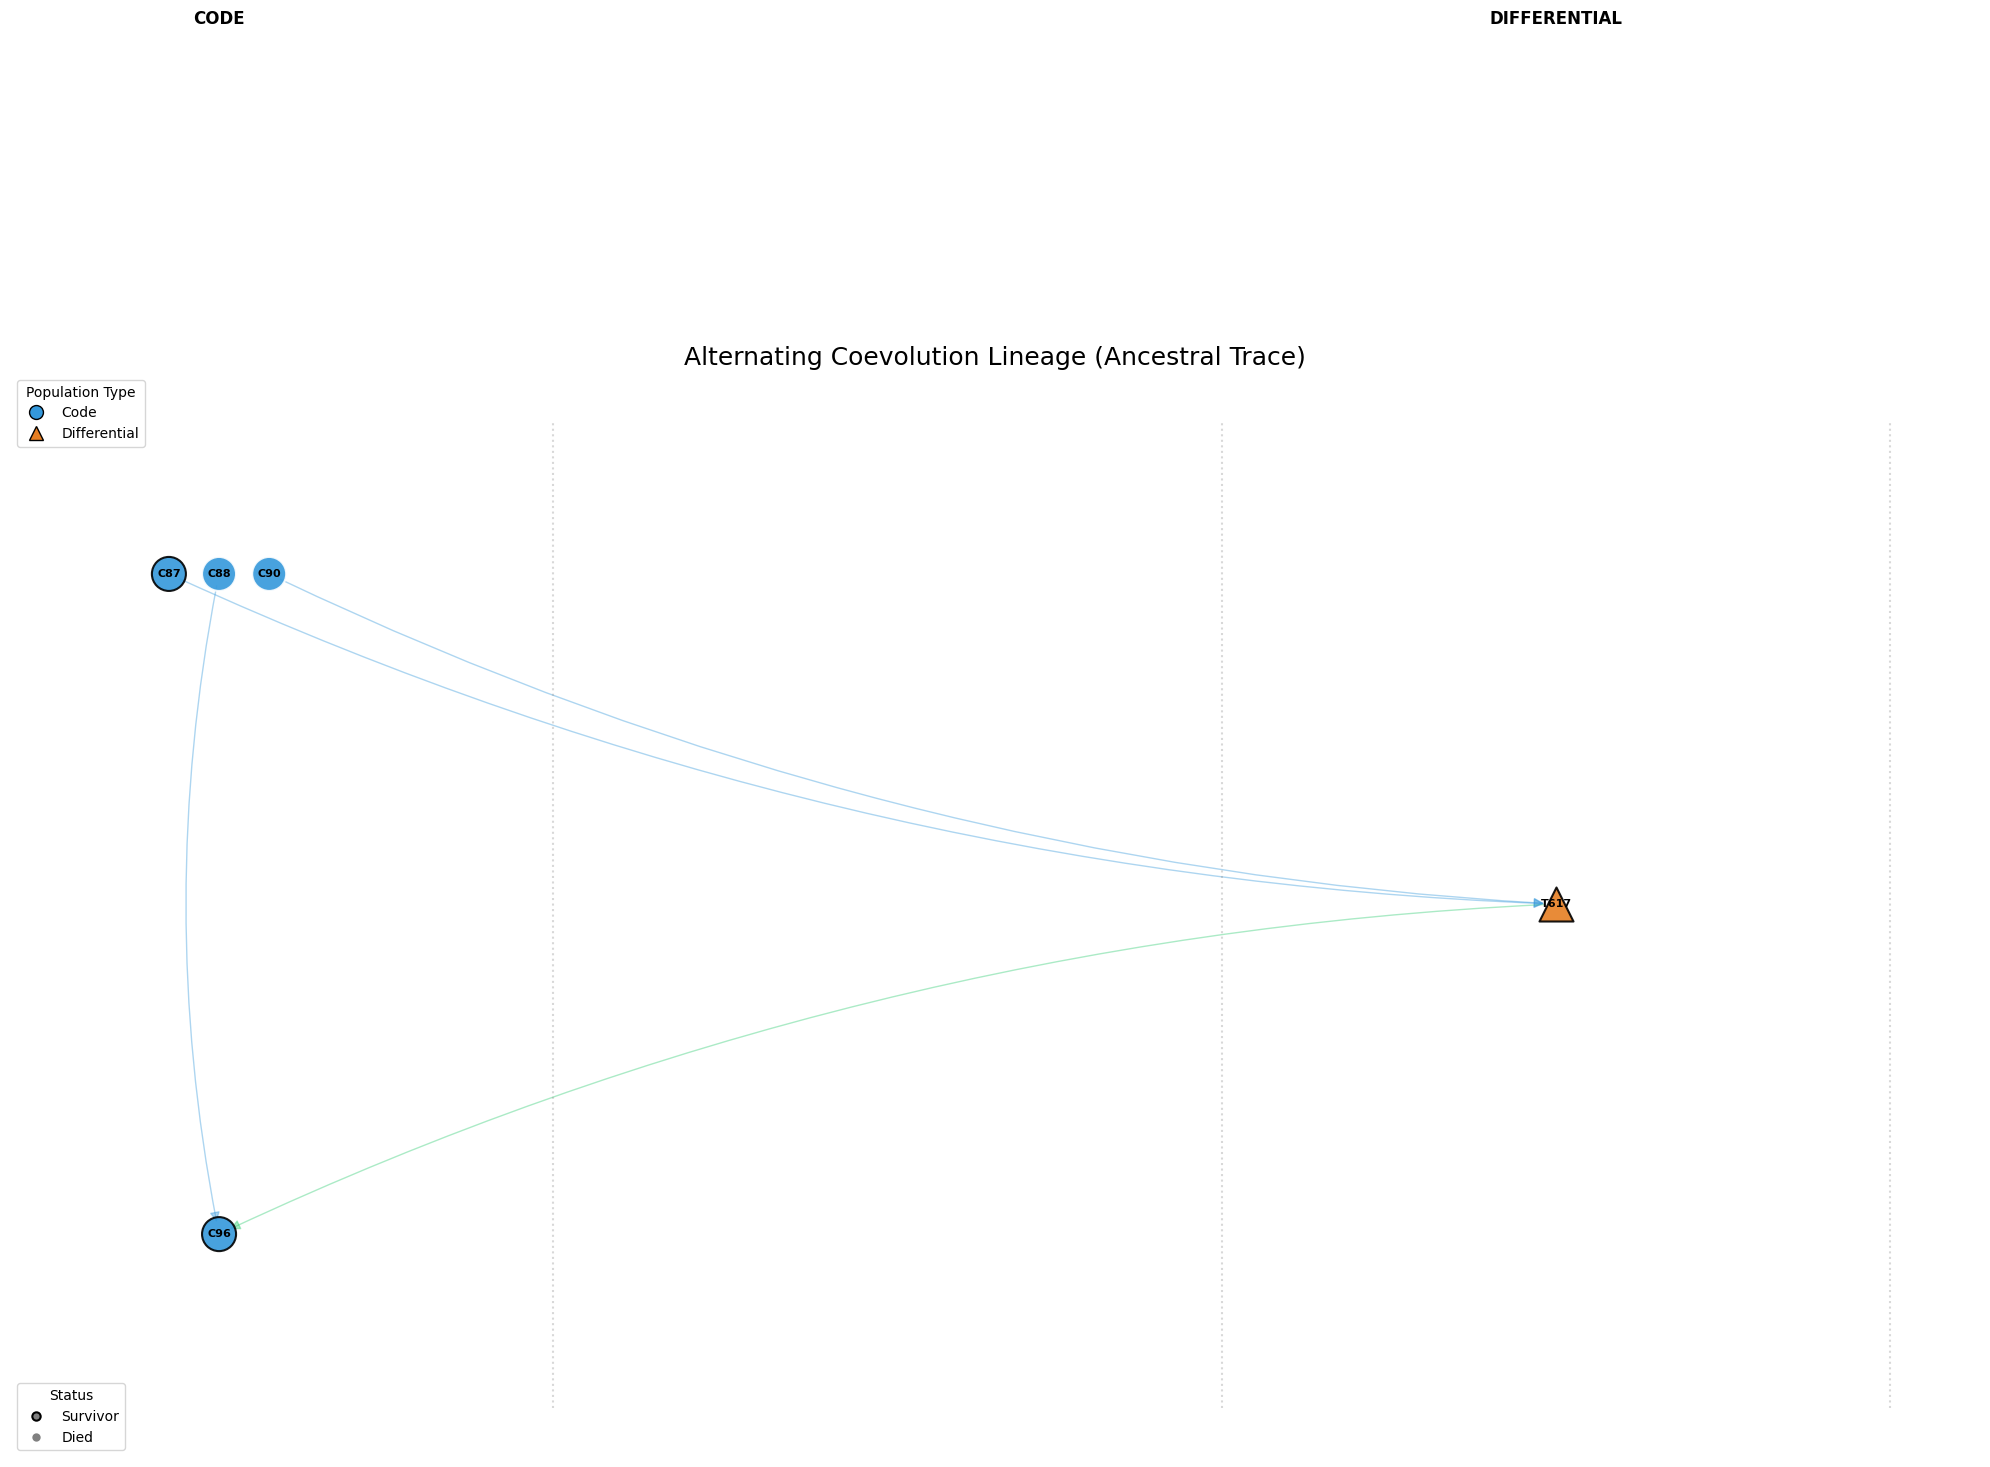

In [38]:
lineage_graph = build_lineage_graph(ind_df)
subgraph = get_ancestral_subgraph(lineage_graph, target_id='C96')
visualize_lineage(subgraph)

In [17]:
for unittest_matrix in unittest_observation_matrices:
    print("\n--- Unittest Observation Matrix ---")
    print(unittest_matrix)


--- Unittest Observation Matrix ---
      T535
Code      
C81      1
C82      1
C83      0
C84      0
C85      0
C86      0
C87      0
C88      0
C89      0
C90      0

--- Unittest Observation Matrix ---
      T535
Code      
C81      1
C82      1
C83      0
C84      0
C85      0
C86      0
C87      0
C88      0
C89      0
C90      0


In [12]:
code_events_df = create_events_df(code_ind_df)
test_events_df = create_events_df(test_ind_df)

ValueError: cannot reindex on an axis with duplicate labels

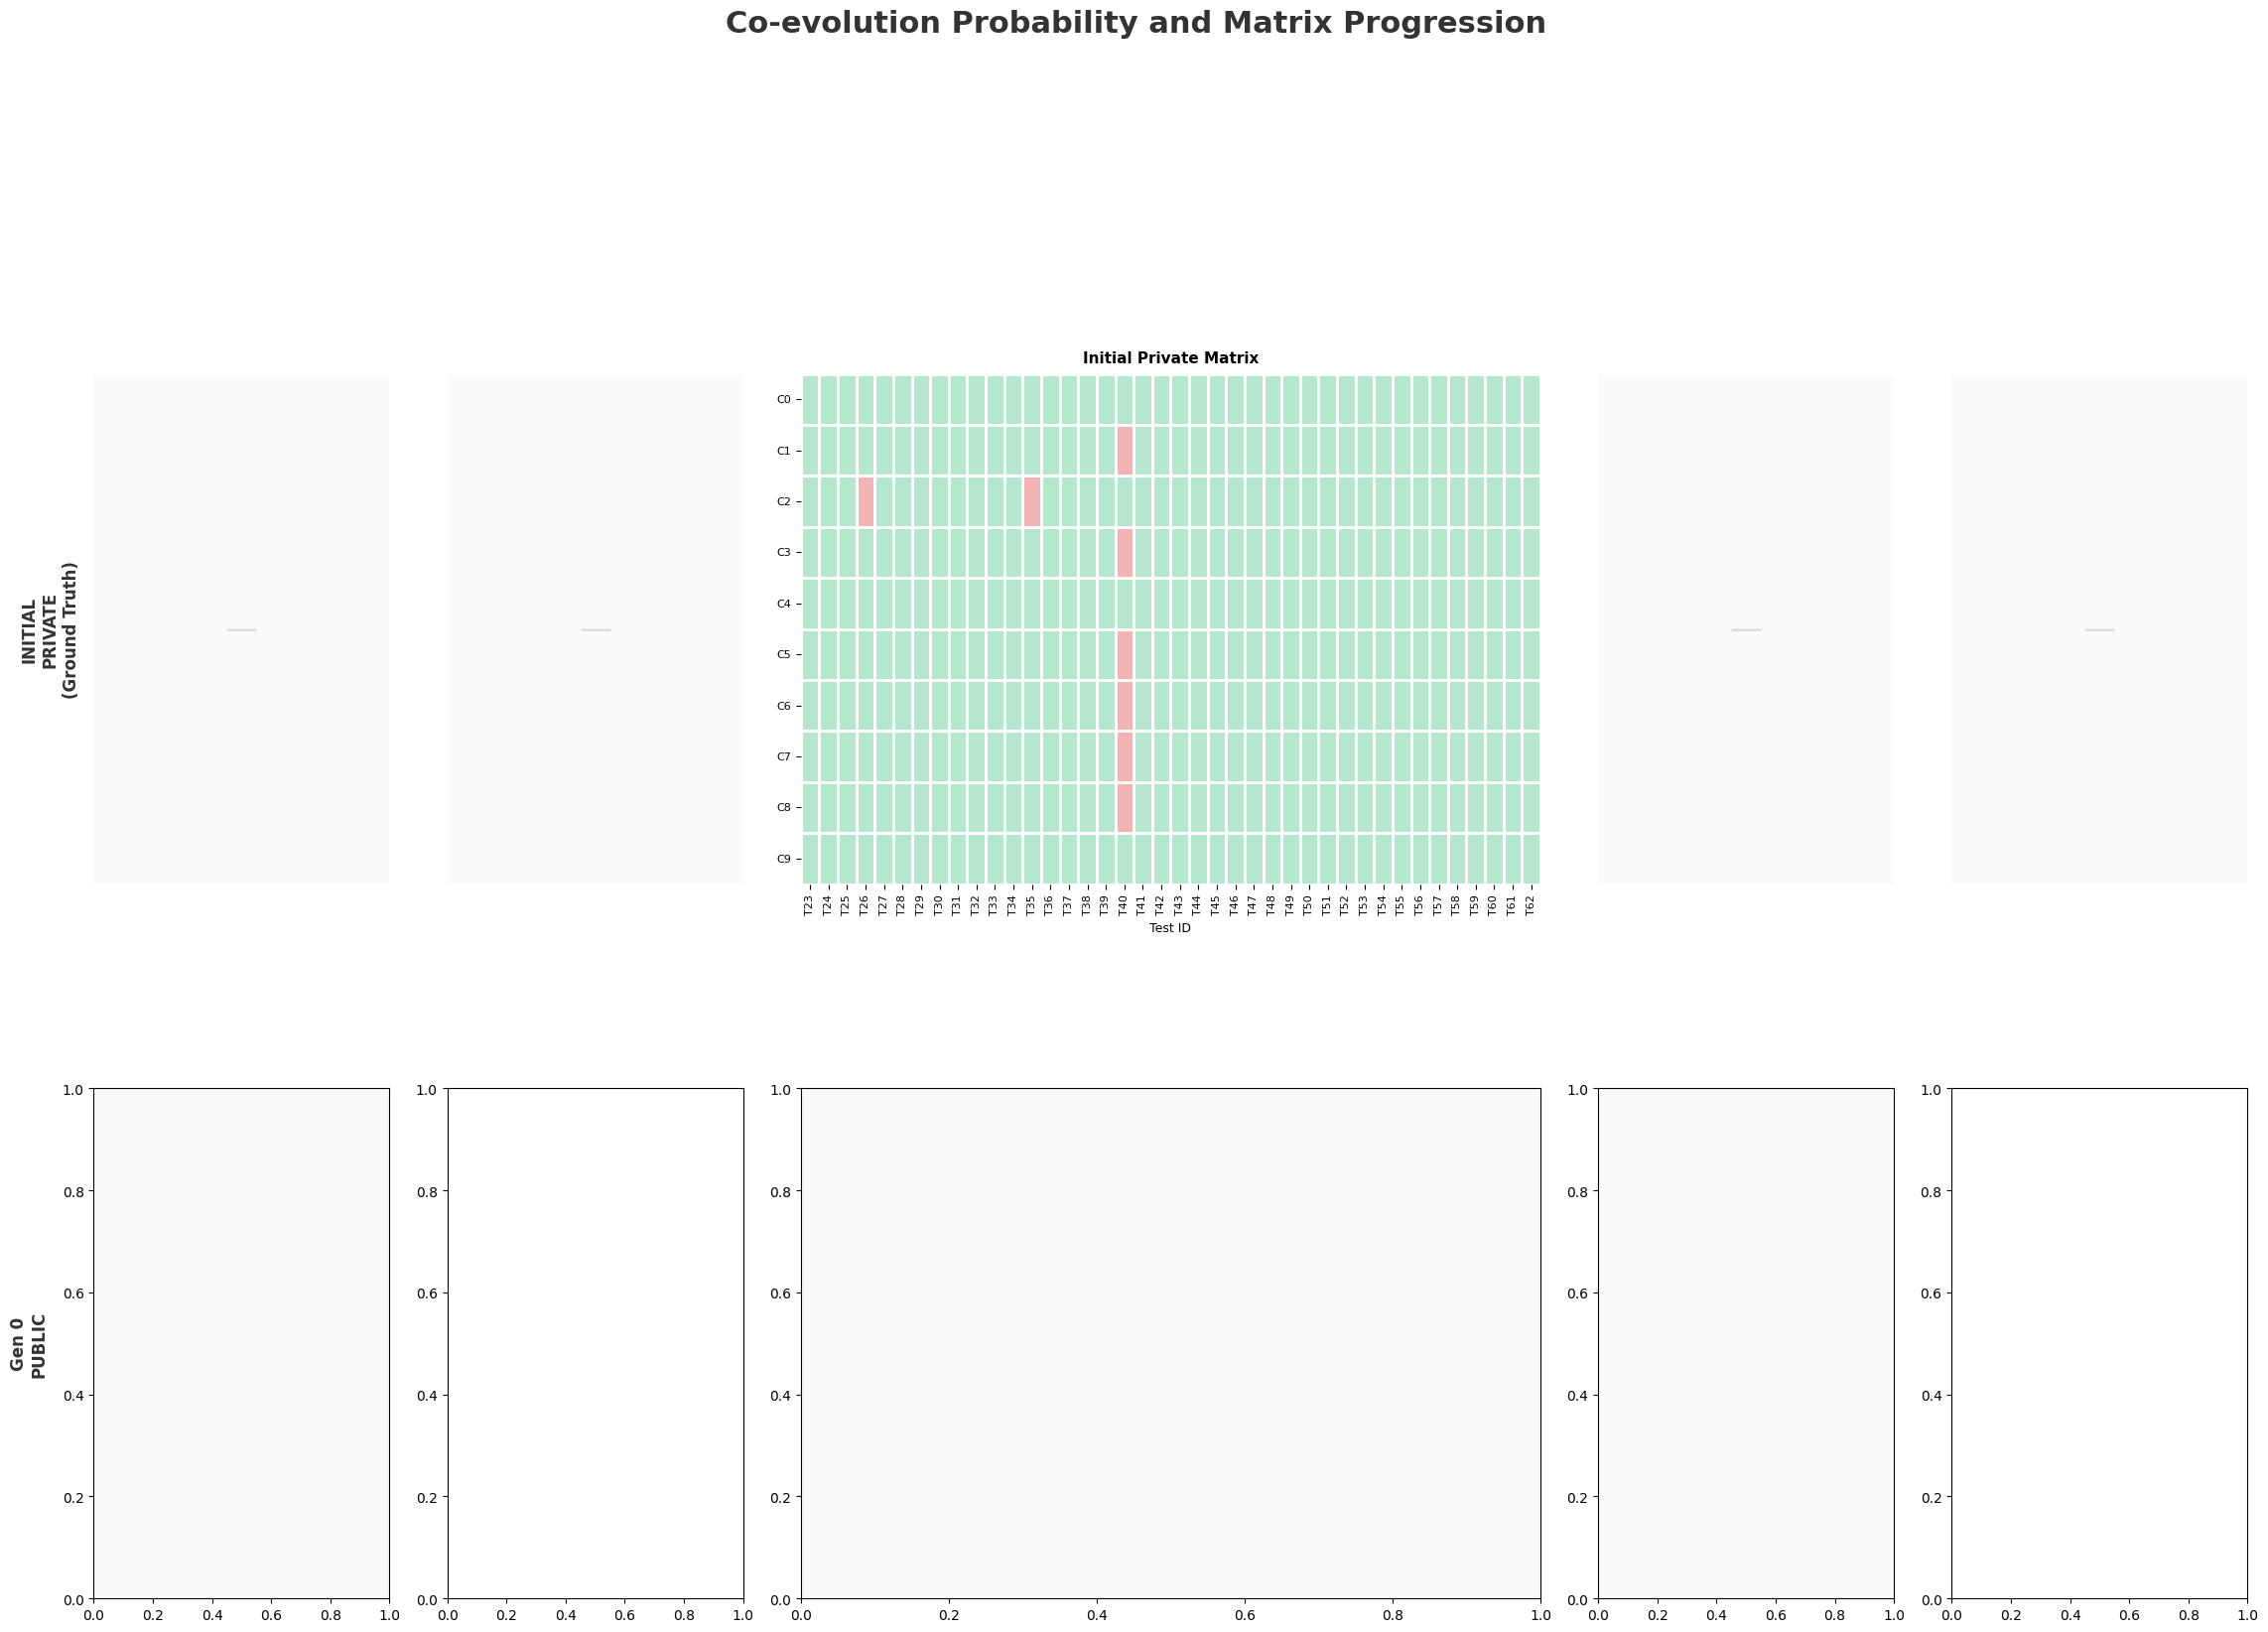

In [13]:
code_progression_df = create_code_progression_df(code_events_df)
test_progression_df = create_test_progression_df(test_events_df)
plot_full_coevolution_dashboard(code_progression_df, test_progression_df, public_observation_matrices, unittest_observation_matrices, private_observation_matrices)

14 [0.15834345 0.24084799]
16 [ 0.14527523 -0.83230444]
12 [-0.35873216 -0.89567797]
13 [-0.86571913 -0.6046891 ]
0 [ 0.53985559 -0.26904855]
15 [-0.27407405  0.46563474]
18 [-0.25703917 -0.33016118]
3 [ 0.91834298 -0.95609626]
4 [ 0.36882455 -0.25295058]
5 [ 0.32129934 -0.31826033]
8 [-0.84605962  0.47070954]
7 [-0.18593053 -0.49699653]
9 [-0.20149788 -0.46341217]


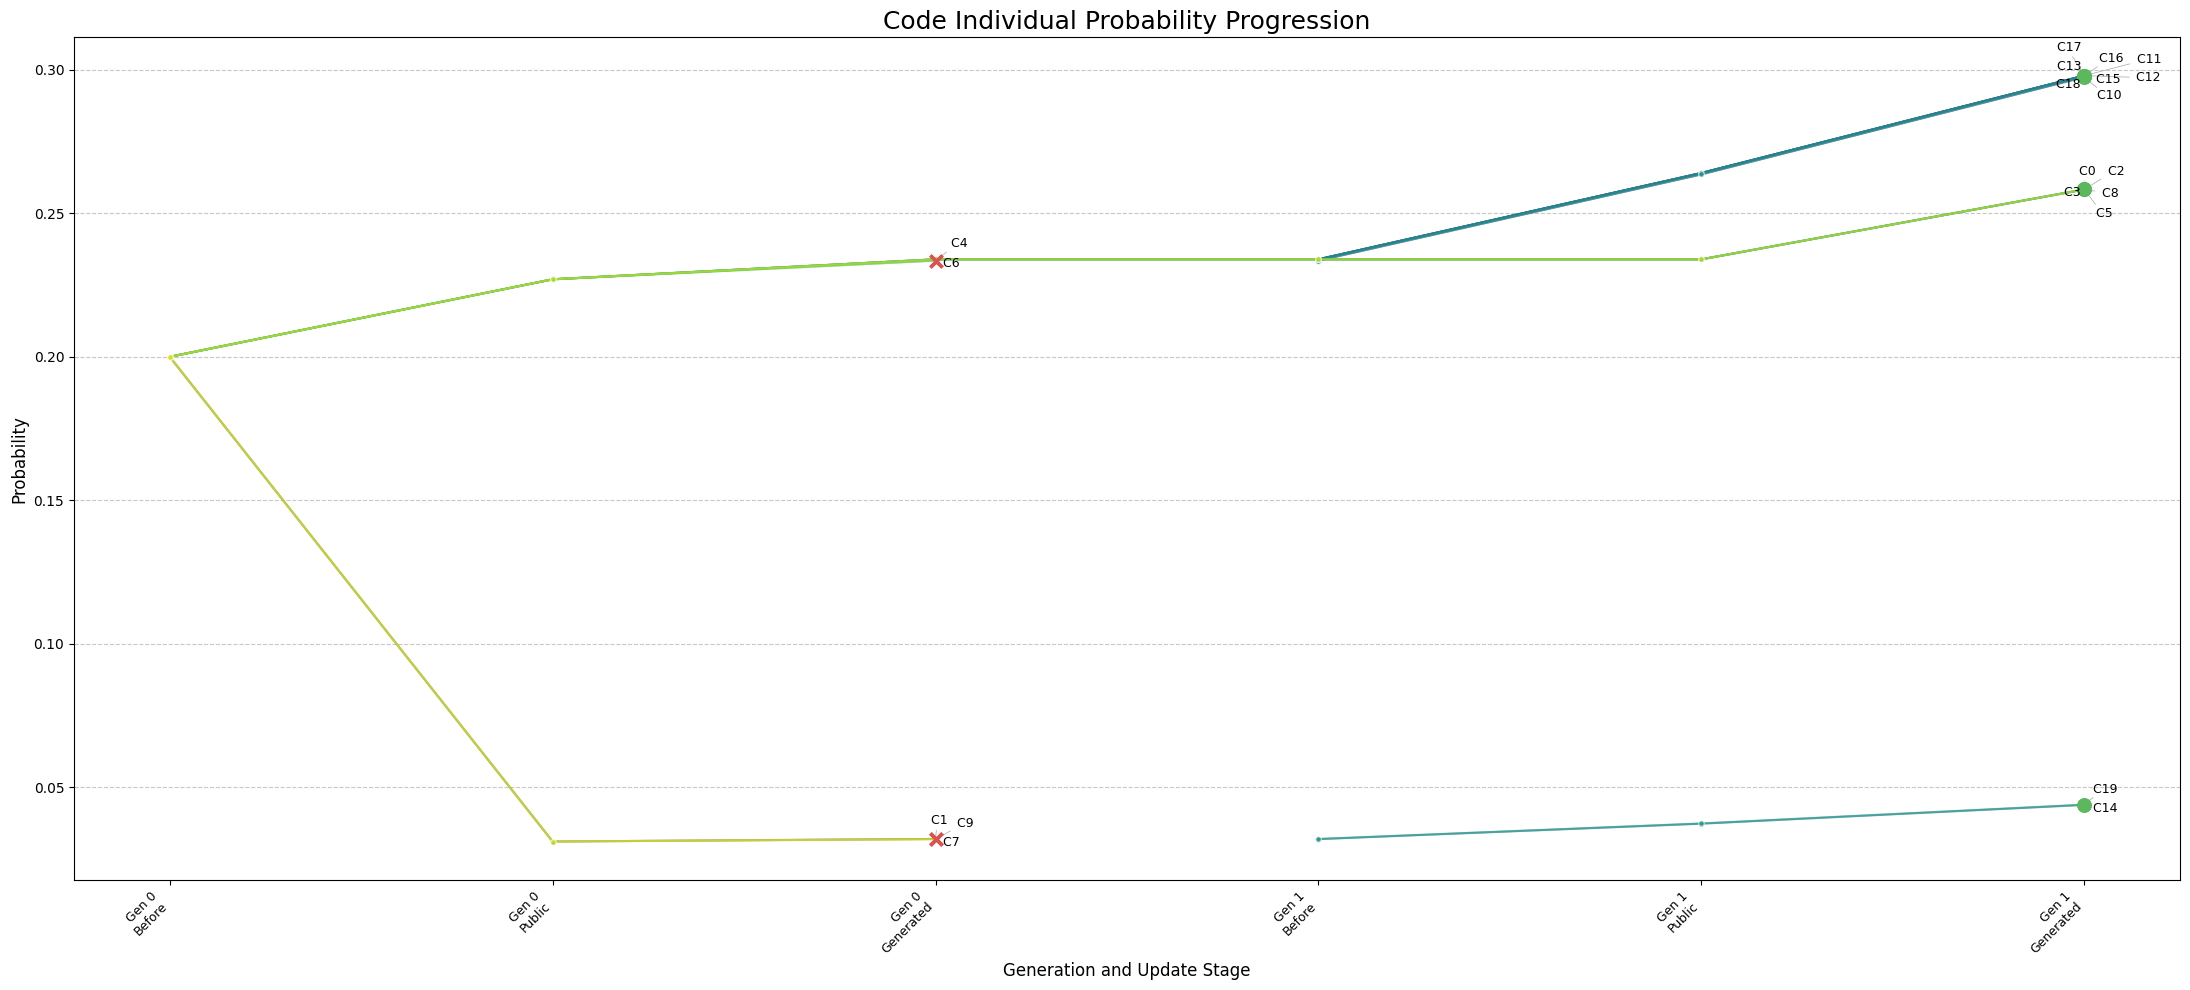

1 [-0.8951309  -0.89070365]
12 [ 0.95804694 -0.38961906]
14 [ 0.81543759 -0.14744447]
16 [-0.19906759 -0.71493228]
25 [0.3369801  0.57046343]
35 [0.54352519 0.30054371]
3 [ 0.65558238 -0.84283192]
4 [-0.79177689  0.23286066]
5 [-0.09612055  0.4322593 ]
6 [0.84712486 0.03388396]
8 [-0.90008174 -0.93781473]
11 [0.24636053 0.84777399]
2 [ 0.74268869 -0.14377282]
7 [ 0.76948321 -0.27152115]
9 [-0.46685689  0.21276896]
10 [-0.36169779  0.3718486 ]
17 [-0.66801214 -0.08262672]
18 [ 0.56612231 -0.88902096]
19 [0.08835417 0.93951559]
22 [-0.6207508  -0.26983847]
23 [0.44627267 0.78750843]
27 [-0.67671674  0.91773667]
28 [0.82105371 0.33989536]
29 [ 0.75376515 -0.81699853]


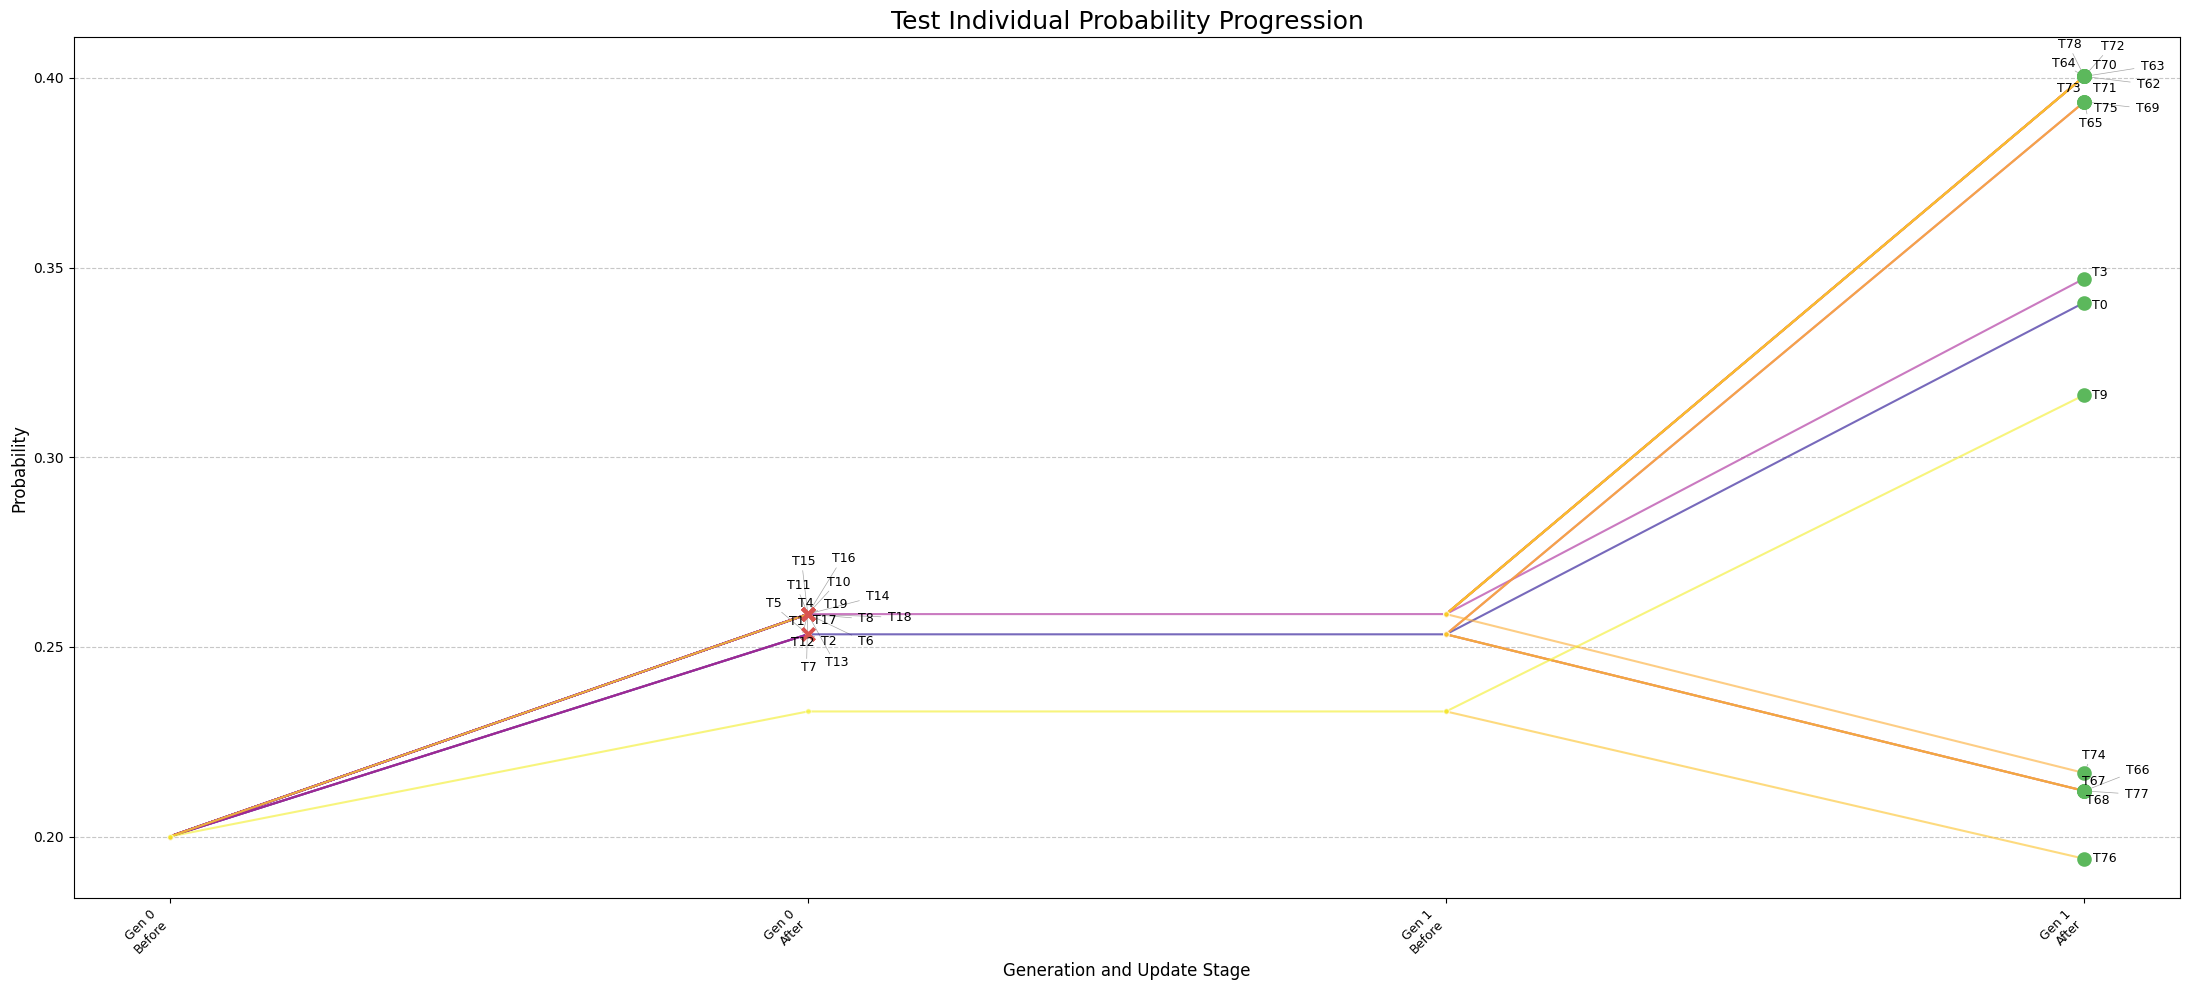

In [35]:
plot_code_probability_progression(code_progression_df)
plot_test_probability_progression(test_progression_df)

# Final Private vs Final Probability

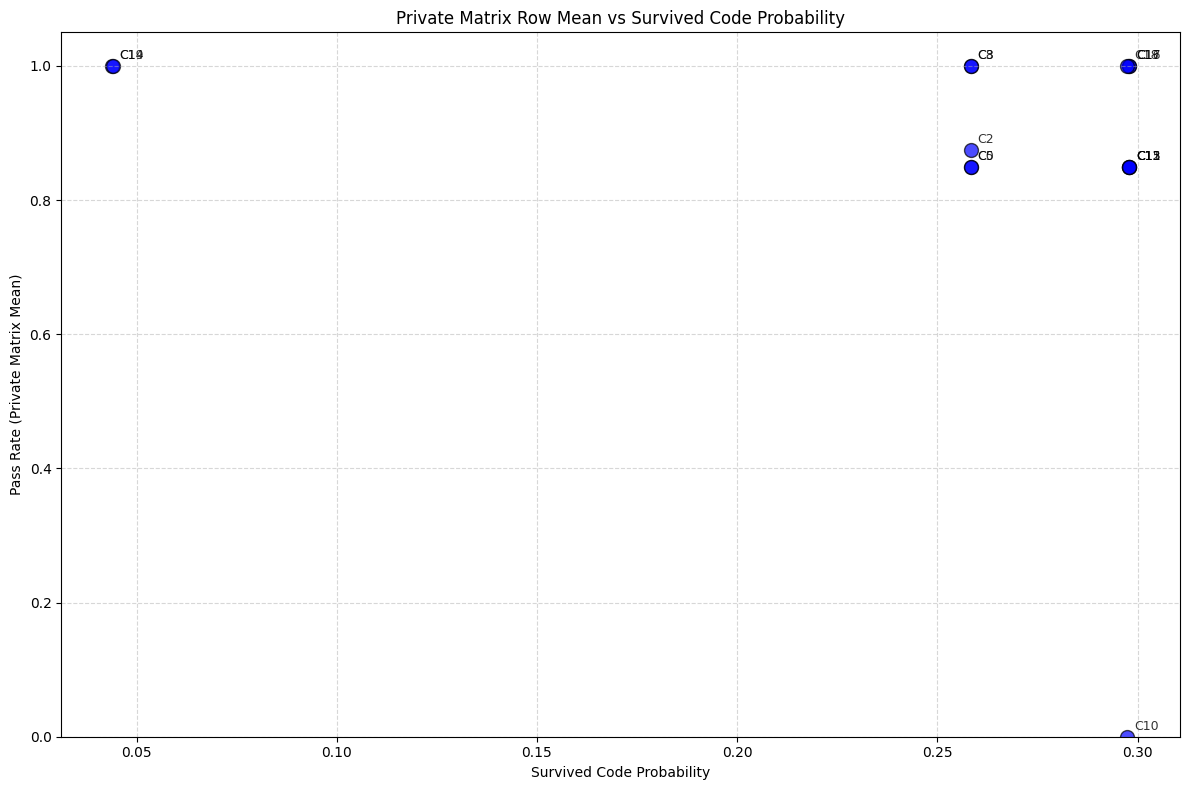

In [36]:
import matplotlib.pyplot as plt
import numpy as np


# Plot private matrix row means vs survived code probabilities on the same axes

# 1) Compute series of row means from the final private matrix
matrix_mean = private_observation_matrices[1].mean(axis=1)

# 2) Survived code probabilities (indexed by id)
surv_prob = (
    code_ind_df[code_ind_df['status'] == 'SURVIVED']
    .loc[:, ['id', 'probability']]
    .set_index('id')['probability']
)

# 3) Combine into a single DataFrame for aligned plotting
plot_df = pd.DataFrame({'matrix_mean': matrix_mean}).join(surv_prob.rename('surv_prob'), how='outer')
plot_df = plot_df.sort_index()


fig, ax = plt.subplots(figsize=(12, 8))

# 1. Scatter Plot
# X-axis: surv_prob
# Y-axis: matrix_mean
scatter = ax.scatter(
    plot_df['surv_prob'], 
    plot_df['matrix_mean'], 
    color='blue', # or COLORS['code'] if available
    s=100, 
    alpha=0.7, 
    edgecolors='k'
)

# 2. Annotate Points
# We iterate through the dataframe to place the Index (ID) next to each dot
for code_id, row in plot_df.iterrows():
    ax.annotate(
        str(code_id), 
        (row['surv_prob'], row['matrix_mean']),
        xytext=(5, 5),       # Slight offset to avoid overlapping the dot
        textcoords='offset points',
        fontsize=9,
        alpha=0.8
    )

# 3. Formatting
ax.set_title('Private Matrix Row Mean vs Survived Code Probability')
ax.set_xlabel('Survived Code Probability')
ax.set_ylabel('Pass Rate (Private Matrix Mean)')
ax.set_ylim(0, 1.05) 
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Initial Populations

In [37]:
for test_ind in test_ind_df[test_ind_df['generation_born']==0].values:
    print(f"\n--- {test_ind[0]} ---")
    print(test_ind[2])


--- T1 ---
def test_basic_no_overlap_pairs(self):
        # n=4, pairs do not share elements: removing one should minimize constraints.
        # Pairs: [1,2], [3,4]. If remove either, remaining forbids only one pair.
        # We compute expected by brute force reasoning:
        # Original array [1,2,3,4]. If remaining forbidden is [3,4], subarrays containing both 3 and 4 are [3,4], [2,3,4], [1,2,3,4] -> 3 excluded.
        # Total subarrays = 10, allowed = 7. Similarly if remaining is [1,2] allowed=7. So max=7.
        n = 4
        pairs = [[1, 2], [3, 4]]
        expected = 7
        self.assertEqual(Solution().maxSubarrays(n, pairs), expected)

--- T2 ---
def test_basic_adjacent_and_far(self):
        # n=5, pairs [2,3] (adjacent), [1,5] (ends). Removing [2,3] leaves only [1,5] forbidden.
        # Subarrays that include both 1 and 5 are only the full array -> 1 excluded. Total subarrays =15 -> allowed 14.
        n = 5
        pairs = [[2, 3], [1, 5]]
        expected = 14
    

In [38]:
for code_ind in code_ind_df[code_ind_df['generation_born']==0].values:
    print(f"\n--- {code_ind[0]} ---")
    print(code_ind[2])


--- C1 ---
from typing import List

class Solution:
    def maxSubarrays(self, n: int, conflictingPairs: List[List[int]]) -> int:
        """
        Approach 2 — Precompute for each left index the earliest conflicting right across all pairs,
        then for each skipped pair update counts using difference arrays (O(n + m)):
        We compute base blocked_right[i] (earliest forbidden right for left=i) considering all pairs.
        For each pair (a,b), we track how base changes if that pair is removed by removing its
        contribution (which was setting blocked_right[a] = min(blocked_right[a], b)).
        We recompute totals efficiently using preprocessing of next smaller endpoints.
        This implementation uses for each pair a local recompute but avoids full O(n) per pair by
        using arrays of positions having the same minimal right. Complexity roughly O(n + m).
        """
        m = len(conflictingPairs)
        if m == 0:
            return n * (n + 1) // 2

       

# Final Population

In [39]:
final_generation = ind_df['generation_born'].max()
for test_ind in test_ind_df[test_ind_df['generation_born']==final_generation].values:
    print(f"\n--- {test_ind[0]} ---")
    print(test_ind[2])




--- T62 ---
def test_overlapping_pairs_and_multiple_minima(self):
    # n=8 tests overlapping pairs, duplicates, and multiple pairs sharing same endpoints
    n = 8
    pairs = [
        [1, 8],  # extreme pair
        [2, 5],
        [2, 5],  # duplicate exact pair
        [3, 6],
        [4, 7],
        [5, 8],
        [1, 4],
        [2, 3],  # small local pair
    ]
    result = Solution().maxSubarrays(n, pairs)
    self.assertIsInstance(result, int)
    # total subarrays is 36; with constraints result must be between 0 and 36
    self.assertTrue(0 <= result <= 36)

--- T63 ---
def test_chain_with_overlapping_second_minima(self):
    # n=8, pairs form chain-like conflicts with overlapping secondary blockers:
    # Pairs: (1,4), (1,3), (3,5), (5,7), (2,6), (2,4)
    # This setup creates starts where the minimal blocker changes and second-min matters.
    n = 8
    pairs = [[1,4],[1,3],[3,5],[5,7],[2,6],[2,4]]
    result = Solution().maxSubarrays(n, pairs)
    self.assertIsInstance(

In [40]:
for code_ind in code_ind_df[code_ind_df['generation_born']==final_generation].values:
    print(f"\n--- {code_ind[0]}:{code_ind[5]:.2f} ---")
    print(code_ind[2])


--- C10:0.30 ---
from typing import List
from collections import defaultdict

class Solution:
    def maxSubarrays(self, n: int, conflictingPairs: List[List[int]]) -> int:
        # Simple correct approach for tests:
        # Try removing each pair (including duplicates) and compute exact count of valid subarrays.
        # This is O(m * n) in worst case but constraints in tests are small enough.
        m = len(conflictingPairs)
        # normalize pairs to (min,max)
        pairs = [(min(a, b), max(a, b)) for a, b in conflictingPairs]
        # helper to count valid subarrays given a set of active pairs
        def count_valid(active_pairs):
            # For quick lookup of forbidden pair membership in a subarray,
            # we can for each pair mark positions a and b and check for any pair both inside.
            # But easiest brute-force: enumerate all O(n^2) subarrays and check.
            cnt = 0
            active_set = set(active_pairs)
            for i in range(1, n +